# COMP8038 - Computational Intelligence I Exam<br><small>Appendix: Case 03. Backpropagation Neural Network<br>2340081121 / Nicholas Dominic<br>BINUS University Graduate Program</small>

In [1]:
import torch
import warnings
from sklearn.preprocessing import MinMaxScaler as mms
from numpy import array
from matplotlib import pyplot as plt

In [2]:
warnings.filterwarnings("ignore") # disable all warnings

**Multi Layer Perceptron**

In [3]:
class FeedForwardNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size, func="sigmoid", calc_details=False, *args, **kwargs):
        
        super(FeedForwardNN, self).__init__()
        
        if func != "sigmoid" and func != "softmax":
            raise AttributeError("sigmoid and softmax activation function only.")
        
        if output_size != 1 and output_size != 3:
            raise ValueError("Please set output_size=1 for Sigmoid or output_size=3 for Softmax.")
        
        if func == "sigmoid" and output_size != 1:
            raise ValueError("If you're using Sigmoid, output_size must be 1.")
        
        self.input_size = input_size
        self.hidden_size  = hidden_size
        self.output_size = output_size
        self.activation_function = func 
        self.calc_details = calc_details
        
        self.fc1 = torch.nn.Linear(self.input_size, self.hidden_size)
        self.fc2 = torch.nn.Linear(self.hidden_size, output_size)
        
        if self.activation_function == "sigmoid":
            self.sigmoid = torch.nn.Sigmoid()
        else:
            self.softmax = torch.nn.Softmax()
        
        self.init_weights()
    
    def init_weights(self, *args, **kwargs):
        initrange = .1
    
        self.fc1.bias.data.zero_()
        self.fc1.weight.data.uniform_(-initrange, initrange)
        self.fc2.bias.data.zero_()
        self.fc2.weight.data.uniform_(-initrange, initrange)

    def forward(self, data, *args, **kwargs):
        params = list(self.parameters())
        
        hidden = self.fc1(data)
        if self.calc_details == True:
            print("-" * 80)
            print("Input Layer -> Hidden Layer")
            for num, i in enumerate(zip(params[0], params[1])):
                for _, j in enumerate(i[0]):
                    print("({:.4f} * {:.4f})".format(j.item(), data[_].item()), "+", end=' ')
                print("{:.4f} =".format(i[1]), end=' ')
                print("{:.4f}".format(hidden[num].item()))
            print("self.fc1(): {}".format(hidden))
        
        output = self.fc2(hidden)
        if self.calc_details == True:
            print("\nHidden Layer -> Output Layer ({})".format(self.activation_function))
            for num, i in enumerate(zip(params[2], params[3])):
                for _, j in enumerate(i[0]):
                    print("({:.4f} * {:.4f})".format(j.item(), hidden[_].item()), "+", end=' ')
                print("{:.4f} =".format(i[1]), end=' ')
                print("{:.4f}".format(output[num].item()))
            print("self.fc2(): {}".format(output))
            
        return self.sigmoid(output) if self.activation_function == "sigmoid" else self.softmax(output)

In [4]:
def fit(model, n_epochs, input_data, target_data, lr, print_details=False):
    criterion = torch.nn.MSELoss() # MSE == Mean Square Error
    sgd_optim = torch.optim.SGD(model.parameters(), lr=lr) # by default, momentum=.9
    
    best_loss = float("inf")
    lowest_loss_epoch = 0
    
    model.train()
    params = list(model.named_parameters())

    model_loss = []
    for epoch in range(1, n_epochs+1):
        # Forward Pass
        y_predict = model(input_data)

        # Backward Pass
        loss = criterion(y_predict, target_data)
        
        model_loss.append(round(loss.item(), 4))
        if loss < best_loss:
            best_loss = round(loss.item(), 4)
            lowest_loss_epoch = epoch
        
        loss.backward()
        if print_details == True:
            for p in params:
                print("\nGradient of {}:".format(p[0]))
                print(p[1].grad)
        
        sgd_optim.step()
        sgd_optim.zero_grad()

        if print_details == True:
            print("-" * 80)
            print("EPOCH {}\ndata: {}\ny_actual: {}\ny_predict: {}\nloss: {}\n".format(epoch, input_data, target_data, y_predict, round(loss.item(), 4)))
            for p in params:
                print(">> Updated Parameter of {}".format(p[0]))
                print(p[1], end="\n\n")
            print(end="\n\n")
        
    return (lowest_loss_epoch, best_loss), model_loss

**Data Preparation for Sigmoid activation function**

In [5]:
data = array([[.5], [1.5], [.5], [2], [2]])
data = mms().fit_transform(data)
data_x, data_y = data[:4], data[4:]

In [6]:
x = torch.tensor([i[0] for i in data_x], dtype=torch.float) # four initial inputs
y_target = torch.tensor([i[0] for i in data_y], dtype=torch.float) # assume Class A = 0, Class B = 1, Class C = 2

In [7]:
x

tensor([0.0000, 0.6667, 0.0000, 1.0000])

In [8]:
y_target

tensor([1.])

**MLP with Sigmoid activation function**

In [9]:
model_sigmoid = FeedForwardNN(4, 5, 1, calc_details=True)

In [10]:
# list of init. parameters
for name, param in model_sigmoid.named_parameters():
    print(name, param, "\n")

fc1.weight Parameter containing:
tensor([[ 0.0240, -0.0048,  0.0204,  0.0718],
        [ 0.0251, -0.0411,  0.0107,  0.0138],
        [ 0.0189, -0.0629,  0.0233, -0.0690],
        [-0.0524,  0.0925,  0.0085,  0.0875],
        [ 0.0584, -0.0459,  0.0329, -0.0972]], requires_grad=True) 

fc1.bias Parameter containing:
tensor([0., 0., 0., 0., 0.], requires_grad=True) 

fc2.weight Parameter containing:
tensor([[-0.0938,  0.0626,  0.0342, -0.0777,  0.0309]], requires_grad=True) 

fc2.bias Parameter containing:
tensor([0.], requires_grad=True) 



In [11]:
fit(model_sigmoid, 2, x, y_target, lr=5, print_details=True)

--------------------------------------------------------------------------------
Input Layer -> Hidden Layer
(0.0240 * 0.0000) + (-0.0048 * 0.6667) + (0.0204 * 0.0000) + (0.0718 * 1.0000) + 0.0000 = 0.0686
(0.0251 * 0.0000) + (-0.0411 * 0.6667) + (0.0107 * 0.0000) + (0.0138 * 1.0000) + 0.0000 = -0.0136
(0.0189 * 0.0000) + (-0.0629 * 0.6667) + (0.0233 * 0.0000) + (-0.0690 * 1.0000) + 0.0000 = -0.1109
(-0.0524 * 0.0000) + (0.0925 * 0.6667) + (0.0085 * 0.0000) + (0.0875 * 1.0000) + 0.0000 = 0.1491
(0.0584 * 0.0000) + (-0.0459 * 0.6667) + (0.0329 * 0.0000) + (-0.0972 * 1.0000) + 0.0000 = -0.1278
self.fc1(): tensor([ 0.0686, -0.0136, -0.1109,  0.1491, -0.1278], grad_fn=<AddBackward0>)

Hidden Layer -> Output Layer (sigmoid)
(-0.0938 * 0.0686) + (0.0626 * -0.0136) + (0.0342 * -0.1109) + (-0.0777 * 0.1491) + (0.0309 * -0.1278) + 0.0000 = -0.0266
self.fc2(): tensor([-0.0266], grad_fn=<AddBackward0>)

Gradient of fc1.weight:
tensor([[ 0.0000,  0.0158,  0.0000,  0.0238],
        [-0.0000, -0.010

((2, 0.048), [0.2567, 0.048])

**Data Preparation for Softmax activation function**

In [12]:
data2 = array([[.5], [1.5], [.5], [2], [0], [1], [2]])
data2 = mms().fit_transform(data2)
data_x2, data_y2 = data2[:4], data2[4:]

In [13]:
x2 = torch.tensor([i[0] for i in data_x2], dtype=torch.float) # four initial inputs
y_target2 = torch.tensor([i[0] for i in data_y2], dtype=torch.float) # assume Class A = 0, Class B = 1, Class C = 2

In [14]:
x2

tensor([0.2500, 0.7500, 0.2500, 1.0000])

In [15]:
y_target2

tensor([0.0000, 0.5000, 1.0000])

**MLP with Softmax activation function**

In [16]:
model_softmax = FeedForwardNN(4, 5, 3, func="softmax", calc_details=True)

In [17]:
# list of init. parameters
for name, param in model_softmax.named_parameters():
    print(name, param, "\n")

fc1.weight Parameter containing:
tensor([[-0.0820,  0.0767,  0.0180, -0.0500],
        [-0.0770, -0.0434, -0.0779, -0.0144],
        [-0.0878,  0.0320, -0.0539,  0.0484],
        [ 0.0190, -0.0769, -0.0037, -0.0282],
        [-0.0822,  0.0940, -0.0562, -0.0924]], requires_grad=True) 

fc1.bias Parameter containing:
tensor([0., 0., 0., 0., 0.], requires_grad=True) 

fc2.weight Parameter containing:
tensor([[-0.0226,  0.0624,  0.0717,  0.0357,  0.0476],
        [-0.0667,  0.0580, -0.0286, -0.0830, -0.0014],
        [-0.0754,  0.0654, -0.0677, -0.0135, -0.0929]], requires_grad=True) 

fc2.bias Parameter containing:
tensor([0., 0., 0.], requires_grad=True) 



In [18]:
fit(model_softmax, 2, x2, y_target2, lr=7, print_details=True)

--------------------------------------------------------------------------------
Input Layer -> Hidden Layer
(-0.0820 * 0.2500) + (0.0767 * 0.7500) + (0.0180 * 0.2500) + (-0.0500 * 1.0000) + 0.0000 = -0.0085
(-0.0770 * 0.2500) + (-0.0434 * 0.7500) + (-0.0779 * 0.2500) + (-0.0144 * 1.0000) + 0.0000 = -0.0857
(-0.0878 * 0.2500) + (0.0320 * 0.7500) + (-0.0539 * 0.2500) + (0.0484 * 1.0000) + 0.0000 = 0.0369
(0.0190 * 0.2500) + (-0.0769 * 0.7500) + (-0.0037 * 0.2500) + (-0.0282 * 1.0000) + 0.0000 = -0.0820
(-0.0822 * 0.2500) + (0.0940 * 0.7500) + (-0.0562 * 0.2500) + (-0.0924 * 1.0000) + 0.0000 = -0.0565
self.fc1(): tensor([-0.0085, -0.0857,  0.0369, -0.0820, -0.0565], grad_fn=<AddBackward0>)

Hidden Layer -> Output Layer (softmax)
(-0.0226 * -0.0085) + (0.0624 * -0.0857) + (0.0717 * 0.0369) + (0.0357 * -0.0820) + (0.0476 * -0.0565) + 0.0000 = -0.0081
(-0.0667 * -0.0085) + (0.0580 * -0.0857) + (-0.0286 * 0.0369) + (-0.0830 * -0.0820) + (-0.0014 * -0.0565) + 0.0000 = 0.0014
(-0.0754 * -0.008

((2, 0.0706), [0.1937, 0.0706])

## Experiment with BPNN

* **Experiment with total hidden layer neurons**<br>Plot MSE Losses for different hidden neurons, i.e., from 2 to 7.

In [19]:
epoch, learning_rate = 1000, 5e-2

In [20]:
mse_loss = []
for i in range(2, 7+1):
    best_loss, all_losses = fit(FeedForwardNN(4, i, 3, func="softmax"), epoch, x2, y_target2, lr=learning_rate)
    mse_loss.append(all_losses)
    print("With hidden neurons = {}, the best MSE loss is {} in epoch {}.".format(i, best_loss[1], best_loss[0]))

With hidden neurons = 2, the best MSE loss is 0.0492 in epoch 1000.
With hidden neurons = 3, the best MSE loss is 0.0458 in epoch 1000.
With hidden neurons = 4, the best MSE loss is 0.0472 in epoch 994.
With hidden neurons = 5, the best MSE loss is 0.0455 in epoch 996.
With hidden neurons = 6, the best MSE loss is 0.0459 in epoch 1000.
With hidden neurons = 7, the best MSE loss is 0.0454 in epoch 996.


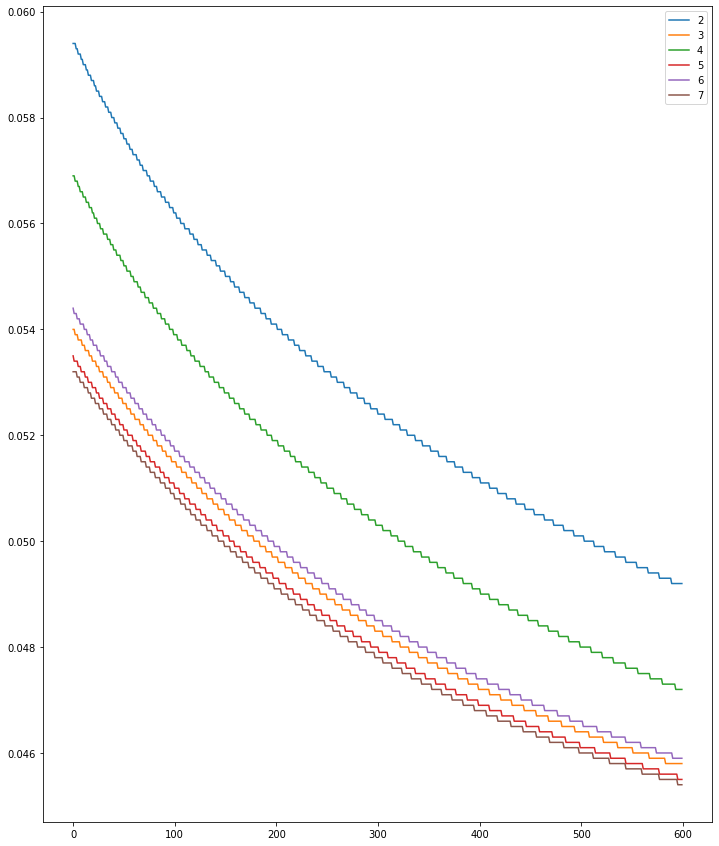

In [21]:
fig = plt.figure(figsize=(12, 15))
for i in range(6):
    plt.plot([i for i in range(600)], mse_loss[i][400:])
    plt.legend([n+2 for n in range(6)])